In [6]:
import os, re, math, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


Device: cuda


In [ ]:
#%pip install pandas

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.2 MB/s eta 0:00:00
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [7]:



SAM2_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/sam2")
# ------------------------------------------
sys.path.insert(0, str(SAM2_REPO))

from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

SAM2_MODEL_CONFIG = SAM2_REPO / "configs/sam2.1/sam2.1_hiera_l.yaml"
SAM2_CHECKPOINT   = SAM2_REPO / "checkpoints/sam2.1_hiera_large.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

sam2_model = build_sam2(str(SAM2_MODEL_CONFIG), str(SAM2_CHECKPOINT), device=device)
sam2_model.eval()

mask_generator = SAM2AutomaticMaskGenerator(sam2_model)
print("SAM2 loaded successfully.")

Using device: cuda


MissingConfigException: Cannot find primary config 'zpool/vladlab/active_drive/omaltz/git_repos/sam2/configs/sam2.1/sam2.1_hiera_l.yaml'. Check that it's in your config search path.

Config search path:
	provider=hydra, path=pkg://hydra.conf
	provider=main, path=pkg://sam2
	provider=schema, path=structured://

In [114]:

# DATA PATHS
PAIRS_DIR  = Path("/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/pairs")

MASK_SIDE = "R"   # "L" or "R"
if MASK_SIDE == "L":
    MASKS_DIR = Path("/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/left_masks")
else:
    MASKS_DIR = Path("/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/right_masks")


OUTPUT_DIR = Path("/zpool/vladlab/data_drive/geogaze_data/cornetS_coco/geogaze_task/identification_geogaze_task")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# CORNET REPO + CHECKPOINT
CORN_NET_REPO = Path("/zpool/vladlab/active_drive/omaltz/git_repos/CORnet")  # your local clone

CKPT_PATH = Path("/zpool/vladlab/data_drive/geogaze_data/cornetS_coco/identification/best_checkpoint.pth.tar")

# TRAINING CONFIG
PAIR_MIDS = ["gs_gc"]     # list, e.g. ["bc_gc", "bc_bs"]
IMG_SIZE = 224
MODEL_TAG = f"cornetIDEN_mask{MASK_SIDE}_{'-'.join(PAIR_MIDS)}"
RUN_DIR = OUTPUT_DIR / MODEL_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)



SEED = 1
EPOCHS = 200
BATCH_SIZE = 32
NUM_WORKERS = 8

VAL_SPLIT = 0.2
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
STEP_SIZE = 10

THRESHOLD = 0.2
POS_WEIGHT = 10   

USE_AMP = (DEVICE.type == "cuda")

print("MASK_SIDE:", MASK_SIDE)
print("PAIR_MIDS:", PAIR_MIDS)
print("CKPT_PATH:", CKPT_PATH)


MASK_SIDE: R
PAIR_MIDS: ['gs_gc']
CKPT_PATH: /zpool/vladlab/data_drive/geogaze_data/cornetS_coco/identification/best_checkpoint.pth.tar


In [115]:
def set_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

set_seed(SEED)


Finds all pair and mask stimulus eligable for the head training stimulus

In [116]:
allowed_mids = [m.strip() for m in PAIR_MIDS if m.strip()]
mid_union = "|".join(re.escape(m) for m in allowed_mids)
PAIR_RE = re.compile(rf"^pair_({mid_union})_(\d+)\.png$")

def mask_path(side, mid, id_):
    p = MASKS_DIR / f"mask{side}_{mid}_{id_}.png"
    return p if p.is_file() else None

def collect_items(side):
    items, skipped = [], 0
    for fn in os.listdir(PAIRS_DIR):
        m = PAIR_RE.match(fn)
        if not m:
            continue
        mid, id_ = m.group(1), m.group(2)
        img_p = PAIRS_DIR / fn
        msk_p = mask_path(side, mid, id_)
        if msk_p is None:
            skipped += 1
            continue
        items.append((img_p, msk_p, mid, id_))
    items.sort(key=lambda x: (x[2], int(x[3])))
    if skipped:
        print(f"[WARN] Skipped {skipped} image(s) with no matching mask{side}.")
    print(f"[INFO] Found {len(items)} (image, mask{side}) pairs across MIDs: {allowed_mids}")
    return items

all_items = collect_items(MASK_SIDE)
assert len(all_items) > 0, "No (image, mask) pairs found."
print("Example item:", all_items[0])


[INFO] Found 500 (image, maskR) pairs across MIDs: ['gs_gc']
Example item: (PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/pairs/pair_gs_gc_0011.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/right_masks/maskR_gs_gc_0011.png'), 'gs_gc', '0011')


Sets ImageNet transforms (resize, tensor, normalize) for train and validation images
Defines how mask images are loaded and converted into binary tensors `(1, H, W)`
Implements a custom Dataset that returns `(image, mask, id)` for each sample
splits the data into train and validation sets using a fixed random seed
Creates PyTorch DataLoader for batching and shuffling
SANITY Check to verify shapes and mask values


In [117]:
# ImageNet normalization (matches typical CORnet training; your training notebook used this)
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# Convert a mask image into a binary tensor (1 = object, 0 = background)
# Assumes the object is encoded as black (pixel value 0)
def load_mask_binary(path: Path):
    """
    Returns mask as float tensor shape (1,H,W) with values in {0,1}.

    IMPORTANT:
    This version matches your earlier segmentation script:
      foreground = 1 where pixel == 0 (black)
    If your masks have foreground in white (255), switch to: (m > 0)
    """
    m = np.asarray(Image.open(path).convert("L"), dtype=np.uint8)
    m = (m == 0).astype(np.float32)   # <-- flip if your mask encoding differs
    return torch.from_numpy(m).unsqueeze(0)

# PyTorch Dataset for paired stimulus images and segmentation masks.
# For each item, this dataset loads a stimulus image and its corresponding
# binary mask, applies ImageNet transforms to the image, converts the
# mask into a (1, H, W) tensor, and returns both along with a unique identifier
# string (mid_id). This dataset is used to feed image–mask pairs into the
# training and validation DataLoaders.
class PairMaskDataset(Dataset):
    # Initialize the dataset with a list of (image_path, mask_path, mid, id) items
    # and the image transforms to apply
    def __init__(self, items, tfms):
        self.items = items
        self.tfms = tfms
    
    # Return the total number of image–mask pairs in the dataset
    def __len__(self):
        return len(self.items)
    
    # Load and return one sample:transformed RGB image tensor, binary mask tensor, identifier string (mid_id)
    def __getitem__(self, i):
        img_p, msk_p, mid, id_ = self.items[i]
        img = Image.open(img_p).convert("RGB")
        x = self.tfms(img)  # (3,224,224)
        y = load_mask_binary(msk_p)  # (1,224,224)
        return x, y, f"{mid}_{id_}"

# Split train/val at random defined by seed 
rng = random.Random(SEED)
shuf = all_items[:]
rng.shuffle(shuf)
n_val = max(1, int(len(shuf) * VAL_SPLIT))
val_items = shuf[:n_val]
trn_items = shuf[n_val:]

print(f"[INFO] Train: {len(trn_items)} | Val: {len(val_items)}")

trainloader = DataLoader(PairMaskDataset(trn_items, train_tfms),
                         batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, pin_memory=True)

valloader = DataLoader(PairMaskDataset(val_items, val_tfms),
                       batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=True)

# Sanity check batch
xb, yb, ids = next(iter(trainloader))
print("x:", xb.shape, xb.dtype)
print("y:", yb.shape, yb.dtype, "unique:", torch.unique(yb))
print("ids[0]:", ids[0])


[INFO] Train: 400 | Val: 100
x: torch.Size([32, 3, 224, 224]) torch.float32
y: torch.Size([32, 1, 224, 224]) torch.float32 unique: tensor([0., 1.])
ids[0]: gs_gc_0419


In [118]:
#getting standard cornet z from gitrepos local clone 

import sys
sys.path.insert(0, str(CORN_NET_REPO))

import cornet
print("Imported cornet from:", cornet.__file__)


Imported cornet from: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py


In [119]:
## LOADING CORNET and REPLACING last classifier layer with the object identification length 80 classifier layer
## build a CORnet-Z model, swap its LAST Linear layer to have 80 or 440 for openimage outputs,
## then load a checkpoint into it and put it in eval mode.

def replace_last_linear(model: nn.Module, out_features: int):
    """
    Find the LAST nn.Linear layer anywhere inside model by walking through all submodules,
    replace it with a new nn.Linear that has the same input size but out_features outputs,
    and return:
      - the updated model
      - the input feature size of the replaced layer (in_features)
      - the full module name of the replaced layer (so we know what got swapped)
    """
    # Track the *most recent Linear layer we see as we iterate
    # After the loop, this will represent the "last" Linear encountered
    last_name, last_linear = None, None
    # Walk through every module in the model including nested ones,
    # keeping the name + module object whenever we see an nn.Linear.
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name, last_linear = name, module

    # If we never found any Linear layer, we can't replace it.
    if last_linear is None:
        raise RuntimeError("No nn.Linear found in model.")
    
    # We need to locate the parent object that contains this layer so we can replace it.
    parent = model
    parts = last_name.split(".")

    # Walk down the attribute chain to get the parent module.
    for p in parts[:-1]:
        parent = getattr(parent, p)

    # Replace the last Linear layer with a new Linear layer with same number of input features as the old layer new number of output features = out_features (80 classes)    
    setattr(parent, parts[-1], nn.Linear(last_linear.in_features, out_features))
    return model, last_linear.in_features, last_name

# Build CORnet-Z so  pretrained=False means start from random initialization (no ImageNet weights)
corn = cornet.cornet_s(pretrained=False)

# run the function that replaces the last linearlayer so the model outputs 80 numbers per image
corn, in_features, last_name = replace_last_linear(corn, out_features=70)
print(f"Replaced {last_name} with Linear({in_features} )")

corn = corn.to(DEVICE)

# Load checkpoint
##map_location is something to makes sure weights load onto gpu correctly.
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    state = ckpt["model_state"]
elif isinstance(ckpt, dict) and "state_dict" in ckpt:
    state = ckpt["state_dict"]
else:
    state = ckpt

missing, unexpected = corn.load_state_dict(state, strict=False)
# Report what happened during loading
print("Loaded ckpt:", CKPT_PATH)
print("Missing keys:", len(missing)) # parameters the model expected but checkpoint didn't have
print("Unexpected keys:", len(unexpected)) #parameters in checkpoint that don't exist in the model

#turns off 
corn.eval()

####OKAY AT THIS POINT WE HAVE THE CORNETZ IDENTIFATION MODEL LOADED WITH ITS CHECKPOINTS


## LOADING CORNET and REPLACING last classifier layer with the object identification length 80 classifier layer
## build a CORnet-Z model, swap its LAST Linear layer to have 80 or 440 for openimage outputs,
## then load a checkpoint into it and put it in eval mode.

def replace_last_linear(model: nn.Module, out_features: int):
    """
    Find the LAST nn.Linear layer anywhere inside model by walking through all submodules,
    replace it with a new nn.Linear that has the same input size but out_features outputs,
    and return:
      - the updated model
      - the input feature size of the replaced layer (in_features)
      - the full module name of the replaced layer (so we know what got swapped)
    """
    # Track the *most recent Linear layer we see as we iterate
    # After the loop, this will represent the "last" Linear encountered
    last_name, last_linear = None, None
    # Walk through every module in the model including nested ones,
    # keeping the name + module object whenever we see an nn.Linear.
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name, last_linear = name, module

    # If we never found any Linear layer, we can't replace it.
    if last_linear is None:
        raise RuntimeError("No nn.Linear found in model.")
    
    # We need to locate the parent object that contains this layer so we can replace it.
    parent = model
    parts = last_name.split(".")

    # Walk down the attribute chain to get the parent module.
    for p in parts[:-1]:
        parent = getattr(parent, p)

    # Replace the last Linear layer with a new Linear layer with same number of input features as the old layer new number of output features = out_features (80 classes)    
    setattr(parent, parts[-1], nn.Linear(last_linear.in_features, out_features))
    return model, last_linear.in_features, last_name

# Build CORnet-Z so  pretrained=False means start from random initialization (no ImageNet weights)
corn = cornet.cornet_s(pretrained=False)

# run the function that replaces the last linearlayer so the model outputs 80 numbers per image
corn, in_features, last_name = replace_last_linear(corn, out_features=70)
print(f"Replaced {last_name} with Linear({in_features} -> not 80 amymore now 440,433)")

corn = corn.to(DEVICE)

# Load checkpoint
##map_location is something to makes sure weights load onto gpu correctly.
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    state = ckpt["model_state"]
elif isinstance(ckpt, dict) and "state_dict" in ckpt:
    state = ckpt["state_dict"]
else:
    state = ckpt

missing, unexpected = corn.load_state_dict(state, strict=False)
# Report what happened during loading
print("Loaded ckpt:", CKPT_PATH)
print("Missing keys:", len(missing)) # parameters the model expected but checkpoint didn't have
print("Unexpected keys:", len(unexpected)) #parameters in checkpoint that don't exist in the model

#turns off 
corn.eval()

####OKAY AT THIS POINT WE HAVE THE CORNETZ IDENTIFATION MODEL LOADED WITH ITS CHECKPOINTS

print("MODEL key example:", list(corn.state_dict().keys())[:5])
print("CKPT  key example:", list(state.keys())[:5])


Replaced module.decoder.linear with Linear(512 )
Loaded ckpt: /zpool/vladlab/data_drive/geogaze_data/cornetS_coco/identification/best_checkpoint.pth.tar
Missing keys: 0
Unexpected keys: 0
Replaced module.decoder.linear with Linear(512 -> not 80 amymore now 440,433)
Loaded ckpt: /zpool/vladlab/data_drive/geogaze_data/cornetS_coco/identification/best_checkpoint.pth.tar
Missing keys: 0
Unexpected keys: 0
MODEL key example: ['module.V1.conv1.weight', 'module.V1.norm1.weight', 'module.V1.norm1.bias', 'module.V1.norm1.running_mean', 'module.V1.norm1.running_var']
CKPT  key example: ['module.V1.conv1.weight', 'module.V1.norm1.weight', 'module.V1.norm1.bias', 'module.V1.norm1.running_mean', 'module.V1.norm1.running_var']


In [120]:


def build_model_for_ckpt(num_classes: int, device="cuda"):
    # This should match FLAGS.model == 'S'
    model = cornet.cornet_s(pretrained=False)

    # IMPORTANT: training code replaced m.decoder.linear where m is model.module if present
    m = model.module if hasattr(model, "module") else model
    m.decoder.linear = nn.Linear(512, num_classes)

    model = model.to(device)
    model.eval()
    return model

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
state = ckpt["state_dict"]  # your ckpt uses state_dict

model = build_model_for_ckpt(num_classes=ckpt["flags"]["num_classes"], device=DEVICE)

missing, unexpected = model.load_state_dict(state, strict=False)
print("Missing:", len(missing))
print("Unexpected:", len(unexpected))
print("First missing:", missing[:20])
print("First unexpected:", unexpected[:20])

keys = list(state.keys())
print("Example keys:", keys[:20])
print("Has any 'norm'?:", any(".norm" in k or ".norm_" in k for k in keys))
print("Has V1.conv1?:", any("V1.conv1" in k for k in keys))
print("Has V1.conv.?:", any("V1.conv." in k for k in keys))


Missing: 0
Unexpected: 0
First missing: []
First unexpected: []
Example keys: ['module.V1.conv1.weight', 'module.V1.norm1.weight', 'module.V1.norm1.bias', 'module.V1.norm1.running_mean', 'module.V1.norm1.running_var', 'module.V1.norm1.num_batches_tracked', 'module.V1.conv2.weight', 'module.V1.norm2.weight', 'module.V1.norm2.bias', 'module.V1.norm2.running_mean', 'module.V1.norm2.running_var', 'module.V1.norm2.num_batches_tracked', 'module.V2.conv_input.weight', 'module.V2.skip.weight', 'module.V2.norm_skip.weight', 'module.V2.norm_skip.bias', 'module.V2.norm_skip.running_mean', 'module.V2.norm_skip.running_var', 'module.V2.norm_skip.num_batches_tracked', 'module.V2.conv1.weight']
Has any 'norm'?: True
Has V1.conv1?: True
Has V1.conv.?: False


In [121]:
import cornet, subprocess, pathlib
print("cornet file:", cornet.__file__)
print("git:", subprocess.check_output(["git","-C", str(pathlib.Path(cornet.__file__).parent), "rev-parse","HEAD"]).decode().strip())



cornet file: /zpool/vladlab/active_drive/omaltz/git_repos/CORnet/cornet/__init__.py
git: d0cc17d4b34ad44dedb01683b70eafd15515adad


In [122]:
from collections import Counter
print(Counter([k.split(".")[2] for k in missing]).most_common(20))  # e.g., norm1/norm2/...


[]


In [123]:
print(corn)

DataParallel(
  (module): Sequential(
    (V1): Sequential(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (nonlin1): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (nonlin2): ReLU(inplace=True)
      (output): Identity()
    )
    (V2): CORblock_S(
      (conv_input): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (skip): Conv2d(128, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (norm_skip): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2d(128, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (no

In [124]:
#####BEGINING OF REPLACING THE LENGTH 80 or 440 or 433 CLASSIFERI HEAD WITH TASK HEAD

# Unwrap DataParallel (get the real CORnet model)
base = corn.module if isinstance(corn, nn.DataParallel) else corn
base = base.to(DEVICE)

In [125]:

# Remove the classifier by deleting the last child
#    This drops: global avg pool + flatten + linear classifier
#    What remains is the CORnet visual encoder (V1 → V2 → V4 → IT)

#  Converts the model’s top top top modules into a list called children like trees 
#  Drops the last child module, which contains the pooling and linear classifier
#  Wraps the remaining modules into a new `nn.Sequential` called `encoder`
#  Moves the encoder to the correct device and sets it to evaluation mode
children = list(base.children())
encoder = nn.Sequential(*children[:-1]).to(DEVICE)
encoder.eval()


Sequential(
  (0): Sequential(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (nonlin1): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (nonlin2): ReLU(inplace=True)
    (output): Identity()
  )
  (1): CORblock_S(
    (conv_input): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (skip): Conv2d(128, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
    (norm_skip): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv1): Conv2d(128, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (nonlin1): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, ker

In [126]:
#show me the child that was removed 
print("Removed last child:")
print(children[-1])

Removed last child:
Sequential(
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (flatten): Flatten()
  (linear): Linear(in_features=512, out_features=70, bias=True)
  (output): Identity()
)


In [127]:
# mask head
# It takes the feature map produced by CORnet
# Uses a 1×1 convolution basically it looks at one pixel at a time and looks at all feature channels at that location with once channe; being one ouput information [0 oe 1] (but will really be using the prediction map)
# The output is a raw mask score map

# this head looks at last layer features annd predicts where object is on image.
class mask_head(nn.Module):
    #inchann is the nuber of channeels in the feautre map, will be 512 coning out of IT
    def __init__(self, in_ch: int):
        #this objects is a subclass of (meaning kind of) nn.Module, so I am initailizing the parent classs
        super().__init__()
        #for every location takes in 512-dimention vector and outputs one channel (one number)
        ##at each space conv2d computes a weighted sun
        self.proj = nn.Conv2d(in_ch, 1, kernel_size=1)
        ##Conv2d builds a weight tensor with shape [1, 512, 1, 1], bias tensor with shape[1], 
        ## if the input is [B, 512, H, W], so at every (h,w) there is a 512 vector, so our output is = suming the vector with wrights aand bias for each space
    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        #feats is the tesor of 
        #doing the math from nn.conv  to get one mask logit per pixel
        logits = self.proj(feats)  # [B, 1, H', W']
        #interloap function upsamples into  into size 224x 224 to match masks again using bilinear interpolation (standard according to shat, align corners is standard according to chat) 
        logits = F.interpolate(logits, size=(224, 224), mode="bilinear", align_corners= False)
        return logits

In [128]:
#See how many features are the output of the encoder so make them the number of features that nee to be the input for the mask head

with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224, device=DEVICE)
    feats = encoder(dummy)
    in_ch = feats.shape[1]

print("Encoder feature shape:", feats.shape)

head = mask_head(in_ch).to(DEVICE)

Encoder feature shape: torch.Size([1, 512, 7, 7])


In [129]:
# 5) Literally puting the mask head on the encoder in one model. 
# cornetmaskmodel has two parts: the CORnet encoder (extracts visual features), the mask head turns features into a pixel-level mask

class CORnetMaskModel(nn.Module):
    def __init__(self, encoder: nn.Module, head: nn.Module):
        super().__init__()
        self.encoder = encoder
        self.head = head
#forward function does the thing but the head is not trained yet you are defining the class of the thing you are making 
#    the image is passed through the encoder to get feature maps
#    the feature maps are passed through the mask head to produce mask logits
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.encoder(x)      # [B, C, H', W']
        logits = self.head(feats)    # [B, 1, 224, 224]
        return logits

model = CORnetMaskModel(encoder, head).to(DEVICE)

In [130]:
# Freeze encoder so there is no training, train only the head
#Disables gradient updates for all encoder parameters 
for p in model.encoder.parameters():
    p.requires_grad = False
#Enables gradient updates for all mask head parameters
for p in model.head.parameters():
    p.requires_grad = True

In [131]:
# Report parameter counts FOR SANITY Trainable feaures should be input size of head
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 513 / 52,904,129


In [132]:
#forward pass shape for sanity to check that putint int two dummy images gets out two mask with one number of channels (0,1) of size 224 x 224
with torch.no_grad():
    x = torch.zeros(2, 3, 224, 224, device=DEVICE)
    y = model(x)
    print("Output mask logits shape:", y.shape)

Output mask logits shape: torch.Size([2, 1, 224, 224])


In [133]:
# Resizes images to 224×224 which they already are but safety step 
# Converts RGB images to tensors
# Normalizes them using ImageNet statistics as the cornet docs say 
img_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),   # safe even if already 224x224
    T.ToTensor(),                     # [0,1], shape [3,H,W]
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

# - Mask preprocessing
#   Loads mask images as grayscale
#   Resizes them with nearest-neighbor interpolation
#  Converts them into **binary masks** where black pixels = object (1) and white pixels = background (0)
#   Outputs masks in shape `[1, 224, 224]`
def load_mask_as_binary_1chw(mask_path):
    m = Image.open(mask_path).convert("L")     # grayscale 0..255
    m = m.resize((IMG_SIZE, IMG_SIZE), resample=Image.NEAREST)
    m = np.array(m, dtype=np.uint8)           # [H,W], 0..255
    m = (m < 128).astype(np.float32)          # black->1, white->0
    m = torch.from_numpy(m).unsqueeze(0)      # [1,H,W]
    return m

# 2) Dataset
# loads one image–mask pair at a time
# Returns a normalized image tensor and its corresponding binary mask
# Uses the list of valid `(image, mask)` pairs collected earlier
class PairMaskDataset(Dataset):
    """
    Returns:
      image: FloatTensor [3,224,224] (normalized)
      mask:  FloatTensor [1,224,224] (0/1, where 1 = object)
    """
    def __init__(self, items, img_transform):
        self.items = items
        self.img_transform = img_transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, mask_path, mid, id_ = self.items[idx]

        # Load RGB image
        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)

        # Load + binarize mask (black = 1, white = 0)
        mask = load_mask_as_binary_1chw(mask_path)

        return img, mask

dataset = PairMaskDataset(all_items, img_tf)

#  Deterministically shuffles the dataset using `SEED the slits the data into training and validation subsets based on `VAL_SPLIT`
#  prints dataset sizes for verification and should be 500 total 400 train 100 validation 
n = len(dataset)
idxs = list(range(n))
random.Random(SEED).shuffle(idxs)

n_val = int(round(n * VAL_SPLIT))
val_idxs = idxs[:n_val]
train_idxs = idxs[n_val:]

train_ds = Subset(dataset, train_idxs)
val_ds   = Subset(dataset, val_idxs)

print(f"Total: {n} , Train: {len(train_ds)}, Val: {len(val_ds)}")

# DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,             # shuffle each epoch
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)
print(all_items)

Total: 500 , Train: 400, Val: 100
[(PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/pairs/pair_gs_gc_0011.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/right_masks/maskR_gs_gc_0011.png'), 'gs_gc', '0011'), (PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/pairs/pair_gs_gc_0023.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/right_masks/maskR_gs_gc_0023.png'), 'gs_gc', '0023'), (PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/pairs/pair_gs_gc_0035.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/right_masks/maskR_gs_gc_0035.png'), 'gs_gc', '0035'), (PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/pairs/pair_gs_gc_0047.png'), PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/right_masks/maskR_gs_gc_0047.png'), 'gs_gc', '0047'), (PosixPath('/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/pairs/pair_gs_gc_0059.png

In [134]:
# Model outputs LOGITS (not probabilities)
# Masks are 0/1 with shape [B, 1, 224, 224]
# BCEWithLogitsLoss applies sigmoid internally
criterion = nn.BCEWithLogitsLoss()
#defines loss function and is a typical loss function for binary segmentation. Each pixel is binarily separatied in object or nonobject (be we are using pred mask anyway)

In [135]:
# Only train the head parameters
# applied the parameters defined above to learning as in cornet docs
#   learning rate (step size for updates) and suggested for fast training 
#   momentum helps stabilize and accelerate learning
#   weight decay is regularization to reduce overfitting
optimizer = torch.optim.SGD(
    model.head.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

In [136]:

# TRAINING LOOP of mask head 
# set best val loss to random to infinity to save best maskhead model
best_val_loss = float("inf")


for epoch in range(EPOCHS):

    # TRAINING PHASE

    #Sets the model to training mode (is only the head becuase we froze the encoder)
    model.train()           
    train_loss = 0.0

    #Iterates over batches from train_loader
    for imgs, masks in train_loader:
        #moves images and masks to the correct device that is gpu should be 
        imgs = imgs.to(DEVICE)      # [B,3,224,224] 
        masks = masks.to(DEVICE)    # [B,1,224,224]

        # Clear old gradients becuase pytorch adds graients by default 
        optimizer.zero_grad()

        # pun a forward pass to predict object mask logits 
        logits = model(imgs)        # [B,1,224,224]

        # computes loss function 
        loss = criterion(logits, masks)

        # backpropogates 
        loss.backward()

        # updates ONLY THE MASK HEAD WEIGHTS BECUASE YOU FROZE THE ENCODER 
        optimizer.step()

        # Averages training loss across all batches to get average loss per batch
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION PHASE that has no learning 
    #Sets the model to evaluation mode 
    model.eval()
    val_loss = 0.0

    #Disables gradient upadting becuase you are not updating any graident 
    with torch.no_grad():
        #Runs the model on validation load to look at all valudation data 
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(imgs)
            loss = criterion(logits, masks)

            #Computes and averages validation loss
            val_loss += loss.item()

    val_loss /= len(val_loader)

    #if the valudation loss is better than the best vlaidation loss then save the model head 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.head.state_dict(), RUN_DIR / "mask_head_best.pt")


    # PRINT PROGRESS
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )


Epoch [1/200] | Train Loss: 0.2417 | Val Loss: 0.2022
Epoch [2/200] | Train Loss: 0.1980 | Val Loss: 0.1573
Epoch [3/200] | Train Loss: 0.1251 | Val Loss: 0.0787
Epoch [4/200] | Train Loss: 0.0416 | Val Loss: 0.0309
Epoch [5/200] | Train Loss: 0.0289 | Val Loss: 0.0290
Epoch [6/200] | Train Loss: 0.0256 | Val Loss: 0.0246
Epoch [7/200] | Train Loss: 0.0242 | Val Loss: 0.0241
Epoch [8/200] | Train Loss: 0.0235 | Val Loss: 0.0234
Epoch [9/200] | Train Loss: 0.0233 | Val Loss: 0.0232
Epoch [10/200] | Train Loss: 0.0229 | Val Loss: 0.0229
Epoch [11/200] | Train Loss: 0.0227 | Val Loss: 0.0227
Epoch [12/200] | Train Loss: 0.0225 | Val Loss: 0.0225
Epoch [13/200] | Train Loss: 0.0222 | Val Loss: 0.0223
Epoch [14/200] | Train Loss: 0.0221 | Val Loss: 0.0222
Epoch [15/200] | Train Loss: 0.0219 | Val Loss: 0.0221
Epoch [16/200] | Train Loss: 0.0216 | Val Loss: 0.0219
Epoch [17/200] | Train Loss: 0.0216 | Val Loss: 0.0219
Epoch [18/200] | Train Loss: 0.0214 | Val Loss: 0.0217
Epoch [19/200] | Tr

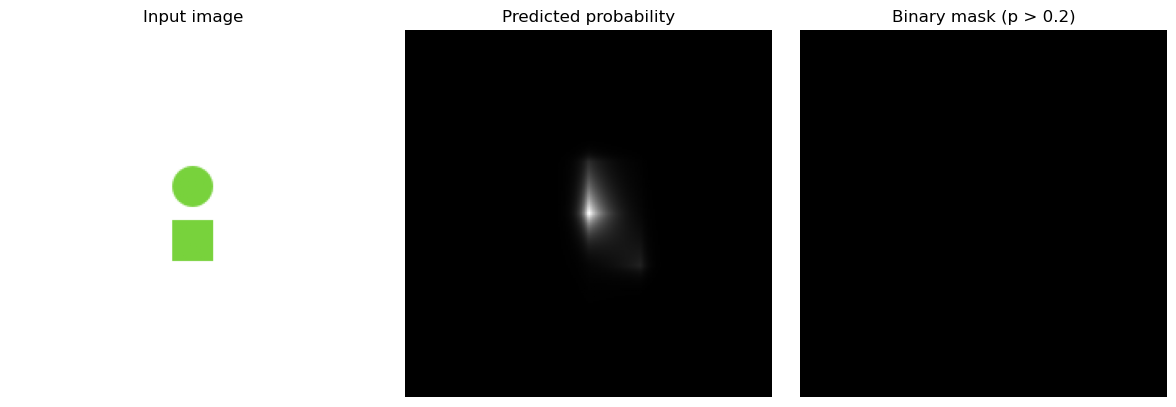

(224, 224)
          0         1         2         3         4         5         6    \
0    0.000057  0.000057  0.000057  0.000057  0.000057  0.000057  0.000057   
1    0.000057  0.000057  0.000057  0.000057  0.000057  0.000057  0.000057   
2    0.000057  0.000057  0.000057  0.000057  0.000057  0.000057  0.000057   
3    0.000057  0.000057  0.000057  0.000057  0.000057  0.000057  0.000057   
4    0.000057  0.000057  0.000057  0.000057  0.000057  0.000057  0.000057   
..        ...       ...       ...       ...       ...       ...       ...   
219  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026   
220  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026   
221  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026   
222  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026   
223  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026   

          7         8         9    ...           214           2

In [137]:

#RUNS ONE PICTURE THROUGH CORNETZWITHMASKHEAD AND GIVES PREDICTION NPARRAY and mask for threshold(no longer using)
TEST_IMG_PATH = Path("/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/test_stimuli/test_pairs/test_gc_gs_UD.png")

# 2) Load + transform the image (use the SAME transform as training)
img_pil = Image.open(TEST_IMG_PATH).convert("RGB")
x = img_tf(img_pil).unsqueeze(0).to(DEVICE)   # [1,3,224,224]

#Put model in evaluation modemodel.eval()
# Run inference without tracking gradients
with torch.no_grad():
    # Forward pass: model outputs raw mask scores that are logits not probabilities
    logits = model(x)                          # [1,1,224,224]
    #Convert logits to probabilities in [0,1] using sigmoid becuase math for some reason --WHAT WE USE NOW NO MORE MASKS OLIVIA 
    probs  = torch.sigmoid(logits)             # [1,1,224,224] probabilities in [0,1]
    #Threshold probabilities to make a hard binary mask (0/1)
    pred   = (probs > THRESHOLD).float()       # [1,1,224,224] binary mask (0/1)

# Convert to numpy for plotting
# Convert the probability map and binary mask into 2D numpy arrays for plotting/saving but didnt work sp use pandas dataframe
prob_map = probs.squeeze().cpu().numpy()       # [224,224]
bin_mask = pred.squeeze().cpu().numpy()        # [224,224]

#undoo imagenet normalization to make it only between normal colors 
img_vis = x.squeeze(0).detach().cpu().clone()  # [3,224,224]
img_vis[0] = img_vis[0] * 0.229 + 0.485
img_vis[1] = img_vis[1] * 0.224 + 0.456
img_vis[2] = img_vis[2] * 0.225 + 0.406
img_vis = img_vis.permute(1, 2, 0).clamp(0, 1).numpy()  # [224,224,3]

# 5) Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_vis)
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(prob_map, cmap="gray")
plt.title("Predicted probability")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bin_mask, cmap="gray")
plt.title(f"Binary mask (p > {THRESHOLD})")
plt.axis("off")

plt.tight_layout()
plt.show()

print(prob_map.shape)

df_pred= pd.DataFrame(prob_map)

print(df_pred)

df_pred.to_csv("output.csv", index=False)


In [138]:
#FINDS MEAN MASK PREDICTION GIVEN A DATAFRAME FOR ONE PICTURE
# Load black/white image -> binary mask DataFrame
# Black object (0)   -> 1
# White background   -> 0
def load_mask_df(img_path: str | Path) -> pd.DataFrame:
    img_path = Path(img_path)

    # Load image as grayscale
    img = Image.open(img_path).convert("L")

    # Enforce size
    if img.size != (224, 224):
        raise ValueError(f"{img_path} has size {img.size}, expected (224, 224)")

    arr = np.array(img, dtype=np.uint8)

    # Threshold to binary: white=1, black=0
    bw = (arr > 127).astype(np.uint8)

    # INVERT so black object becomes 1
    mask = 1 - bw

    return pd.DataFrame(mask)


# Ensure x is valid
def prepare_x(x: pd.DataFrame | np.ndarray) -> np.ndarray:
    if isinstance(x, pd.DataFrame):
        x = x.to_numpy()

    if x.shape != (224, 224):
        raise ValueError(f"x has shape {x.shape}, expected (224, 224)")

    x = x.astype(np.float32)

    if x.min() < 0 or x.max() > 1:
        raise ValueError("x must contain values between 0 and 1")

    return x


# Compute masked mean
def masked_mean(x: np.ndarray, mask: np.ndarray, name: str) -> float:
    sel = mask == 1
    n = sel.sum()

    if n == 0:
        raise ValueError(f"{name} mask contains zero object pixels")

    return float(x[sel].mean())


# Main computation
def compute_target_vs_distractor_means(
    x: pd.DataFrame | np.ndarray,
    target_img: str | Path,
    distractor_img: str | Path,
) -> dict:

    x = prepare_x(x)

    target_mask = load_mask_df(target_img).to_numpy()
    distractor_mask = load_mask_df(distractor_img).to_numpy()

    return {
        "target_mean": masked_mean(x, target_mask, "target"),
        "distractor_mean": masked_mean(x, distractor_mask, "distractor"),
        "n_target_pixels": int(target_mask.sum()),
        "n_distractor_pixels": int(distractor_mask.sum()),
    }


if __name__ == "__main__":

    
    x = df_pred

    target_img = "/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/test_stimuli/test_acc_masks/test_down_c_mask.png"
    distractor_img = "/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/test_stimuli/test_acc_masks/test_up_s_mask.png"

    results = compute_target_vs_distractor_means(
        x=x,
        target_img=target_img,
        distractor_img=distractor_img,
    )

    print(results)


{'target_mean': 0.01693035662174225, 'distractor_mean': 0.026956280693411827, 'n_target_pixels': 489, 'n_distractor_pixels': 625}


In [139]:
print(RUN_DIR)

/zpool/vladlab/data_drive/geogaze_data/cornetS_coco/geogaze_task/identification_geogaze_task/cornetIDEN_maskR_gs_gc


In [140]:
###Run all test critical images in a folder through the model and save the pred_map as csvs 

TEST_IMG_DIR = Path("/zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/test_stimuli/identification/test_images")

PRED_MAP_FOLDER = TEST_IMG_DIR / MODEL_TAG

# File extensions to process
EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp")

# Assumes these already exist from your notebook:
#   model (your CORnet+maskhead model)
#   img_tf (the SAME transform as training)
#   DEVICE (e.g., "cuda" or "cpu")

# RUN BATCH INFERENCE
model.eval()

image_paths = [p for p in PRED_MAP_FOLDER.iterdir() if p.is_file() and p.suffix.lower() in EXTS]
print(f"Found {len(image_paths)} images in: {PRED_MAP_FOLDER}")

with torch.no_grad():
    for img_path in sorted(image_paths):
        # 1) Load image
        img_pil = Image.open(img_path).convert("RGB")

        # 2) Transform + add batch dim + move to device
        x = img_tf(img_pil).unsqueeze(0).to(DEVICE)  # [1,3,224,224]

        # 3) Forward pass
        logits = model(x)                 # [1,1,224,224]
        probs  = torch.sigmoid(logits)    # [1,1,224,224]

        # 4) Convert prob map to numpy (224x224)
        prob_map = probs.squeeze().detach().cpu().numpy()  # [224,224]

        # 5) Save as CSV named {image_name}_prob_map.csv
        out_name = f"{img_path.stem}_prob_map.csv"
        out_path = RUN_DIR / out_name

        df_prob = pd.DataFrame(prob_map)
        df_prob.to_csv(out_path, index=False)

        print(f"Saved: {out_path}")


Found 6 images in: /zpool/vladlab/data_drive/geogaze_data/decoder_stimulus/test_stimuli/identification/test_images/cornetIDEN_maskR_gs_gc
Saved: /zpool/vladlab/data_drive/geogaze_data/cornetS_coco/geogaze_task/identification_geogaze_task/cornetIDEN_maskR_gs_gc/test_gc_gc_LR_prob_map.csv
Saved: /zpool/vladlab/data_drive/geogaze_data/cornetS_coco/geogaze_task/identification_geogaze_task/cornetIDEN_maskR_gs_gc/test_gc_gs_LR_prob_map.csv
Saved: /zpool/vladlab/data_drive/geogaze_data/cornetS_coco/geogaze_task/identification_geogaze_task/cornetIDEN_maskR_gs_gc/test_gc_gs_UD_prob_map.csv
Saved: /zpool/vladlab/data_drive/geogaze_data/cornetS_coco/geogaze_task/identification_geogaze_task/cornetIDEN_maskR_gs_gc/test_gs_gc_LR_prob_map.csv
Saved: /zpool/vladlab/data_drive/geogaze_data/cornetS_coco/geogaze_task/identification_geogaze_task/cornetIDEN_maskR_gs_gc/test_gs_gc_UD_prob_map.csv
Saved: /zpool/vladlab/data_drive/geogaze_data/cornetS_coco/geogaze_task/identification_geogaze_task/cornetIDEN_m